# Phase 3 — Anomaly Detection
### Energy Demand Forecasting Project

Phase 2 already showed that the STL residual "anomalies" mostly line up with
known data-collection gaps (Phase 1). So the goal here is sharper: separate
**infrastructure anomalies** (meter/logger outages — already known) from
**behavioral anomalies** (days the household genuinely consumed power in an
unusual way) using four independent methods, then see where they agree.

Methods: Z-score, rolling IQR, STL residuals, Isolation Forest (multivariate).


In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import holidays

plt.rcParams["figure.figsize"] = (14, 5)
sns.set_style("whitegrid")


## Load data

In [4]:
con = duckdb.connect("../data/energy.duckdb")
daily = con.execute("SELECT * FROM daily ORDER BY datetime").df()
daily["datetime"] = pd.to_datetime(daily["datetime"])
daily = daily.set_index("datetime")

print(f"Daily rows: {len(daily)}")
daily.head()


Daily rows: 1442


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.0,546.0,4926.0
2006-12-17,2.354486,0.156949,240.087028,9.999028,2033.0,4187.0,13341.0
2006-12-18,1.530435,0.112356,241.231694,6.421667,1063.0,2621.0,14018.0
2006-12-19,1.157079,0.104821,241.999313,4.926389,839.0,7602.0,6197.0
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.0,2648.0,14063.0


## Known infrastructure gaps (from Phase 1 / Phase 2)

These 8 days are already-explained data outages, not behavioral anomalies.
We carry them forward so we can separate "already known" from "new finding"
in the results below, rather than re-discovering and re-explaining them.


In [5]:
KNOWN_GAP_DATES = pd.to_datetime([
    "2007-04-29", "2009-06-14", "2010-01-13",
    "2010-08-19", "2010-08-20", "2010-08-21",
    "2010-09-26", "2010-09-27",
])
print(f"{len(KNOWN_GAP_DATES)} known infrastructure-gap dates carried forward from Phase 1/2.")


8 known infrastructure-gap dates carried forward from Phase 1/2.


## Method 1 — Z-score

**Two versions, deliberately:**
1. **Naive z-score** on the raw series — flags statistically extreme days,
   but conflates real seasonal extremes (e.g. the single coldest winter day)
   with true anomalies, since it doesn't account for the seasonal cycle at all.
2. **Seasonally-adjusted z-score** — z-score of the STL *residual* instead of
   the raw value, so a cold winter day that's merely "typical for winter"
   won't get flagged just for being high in absolute terms.

Showing both so the naive version's weakness is visible rather than hidden.


In [6]:
series = daily["global_active_power"]

# --- Naive z-score on raw series ---
z_raw = (series - series.mean()) / series.std()
flag_zscore_raw = z_raw.abs() > 3

# --- STL residual z-score (seasonally adjusted) ---
series_filled = series.interpolate(limit_direction="both")  # STL needs no NaNs
stl = STL(series_filled, period=7, robust=True).fit()
resid = stl.resid
z_resid = (resid - resid.mean()) / resid.std()
flag_zscore_stl = z_resid.abs() > 3

print(f"Naive z-score flags: {flag_zscore_raw.sum()} days")
print(f"STL-residual z-score flags: {flag_zscore_stl.sum()} days")


Naive z-score flags: 13 days
STL-residual z-score flags: 38 days


## Method 2 — Rolling IQR

Uses a trailing 30-day window's Q1/Q3 to set bounds, so what counts as
"unusual" adapts to the local season rather than using one fixed
whole-history threshold. This makes it more context-aware than the naive
z-score, though still simpler than STL.


In [7]:
window = 30
rolling_q1 = series.rolling(window, min_periods=10).quantile(0.25)
rolling_q3 = series.rolling(window, min_periods=10).quantile(0.75)
rolling_iqr = rolling_q3 - rolling_q1

lower_bound = rolling_q1 - 1.5 * rolling_iqr
upper_bound = rolling_q3 + 1.5 * rolling_iqr

flag_iqr = (series < lower_bound) | (series > upper_bound)
print(f"Rolling IQR flags: {flag_iqr.sum()} days")


Rolling IQR flags: 57 days


## Method 3 — STL Residual Anomalies

Same STL fit as Method 1's seasonally-adjusted z-score, but here we look at
the residual magnitude directly (not z-scored) to double check consistency,
and plot it so we can see *where* residual anomalies cluster in time.


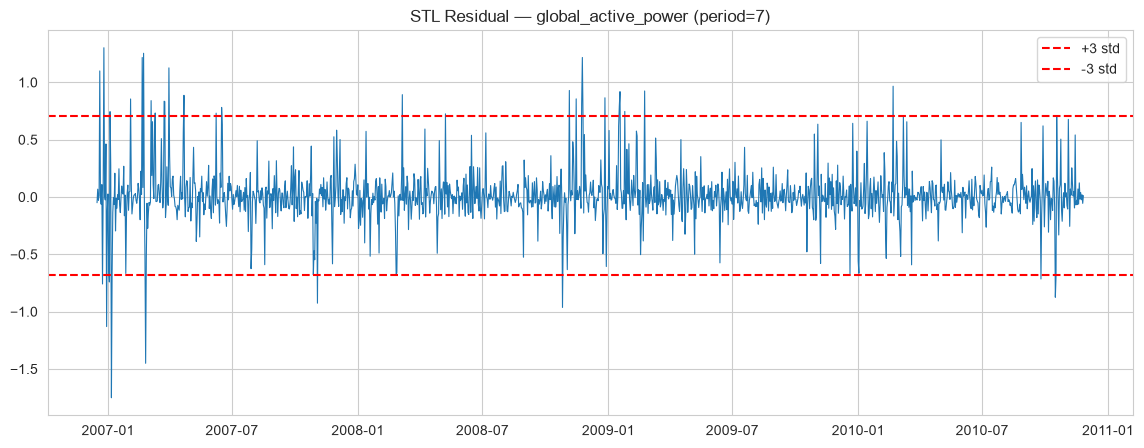

In [8]:
fig, ax = plt.subplots()
ax.plot(resid.index, resid.values, linewidth=0.8)
ax.axhline(resid.mean() + 3 * resid.std(), color="red", linestyle="--", label="+3 std")
ax.axhline(resid.mean() - 3 * resid.std(), color="red", linestyle="--", label="-3 std")
ax.set_title("STL Residual — global_active_power (period=7)")
ax.legend()
plt.show()

flag_stl_resid = flag_zscore_stl  # same criterion, reused


## Method 4 — Isolation Forest (multivariate)

The first three methods only look at `global_active_power` in isolation.
Isolation Forest looks across **all** electrical variables at once, so it
can catch a day that looks normal on total power but unusual in its
*combination* of features — e.g. unusually high voltage with normal power,
or a strange split between sub-metering channels.

Rows with any missing value are excluded (they're the known gap days, and
Isolation Forest can't handle NaN anyway).


In [9]:
feature_cols = [
    "global_active_power", "global_reactive_power", "voltage", "global_intensity",
    "sub_metering_1", "sub_metering_2", "sub_metering_3",
]

daily_complete = daily.dropna(subset=feature_cols)
print(f"Rows used for Isolation Forest: {len(daily_complete)} (dropped {len(daily) - len(daily_complete)} rows with missing values)")

scaler = StandardScaler()
X = scaler.fit_transform(daily_complete[feature_cols])

iso_forest = IsolationForest(contamination=0.02, random_state=42)
iso_pred = iso_forest.fit_predict(X)  # -1 = anomaly, 1 = normal

flag_isoforest = pd.Series(iso_pred == -1, index=daily_complete.index)
flag_isoforest = flag_isoforest.reindex(daily.index, fill_value=False)  # align back to full date range

print(f"Isolation Forest flags: {flag_isoforest.sum()} days")


Rows used for Isolation Forest: 1434 (dropped 8 rows with missing values)
Isolation Forest flags: 29 days


## Consolidating results

Building one table with a flag per method per day, plus a count of how many
methods agree. Higher agreement = higher confidence this is a genuine,
worth-investigating anomaly rather than one method's quirk.


In [10]:
anomaly_table = pd.DataFrame({
    "global_active_power": daily["global_active_power"],
    "zscore_raw": flag_zscore_raw,
    "zscore_stl": flag_zscore_stl,
    "rolling_iqr": flag_iqr,
    "isolation_forest": flag_isoforest,
})

flag_cols = ["zscore_raw", "zscore_stl", "rolling_iqr", "isolation_forest"]
anomaly_table["n_methods_flagged"] = anomaly_table[flag_cols].sum(axis=1)
anomaly_table["is_known_gap"] = anomaly_table.index.isin(KNOWN_GAP_DATES)

top_anomalies = anomaly_table[anomaly_table["n_methods_flagged"] >= 2].sort_values(
    "n_methods_flagged", ascending=False
)
print(f"Days flagged by 2+ methods: {len(top_anomalies)}")
top_anomalies


Days flagged by 2+ methods: 27


,global_active_power,zscore_raw,zscore_stl,rolling_iqr,isolation_forest,n_methods_flagged,is_known_gap
datetime,,,,,,,
2008-11-23,2.366253,True,True,True,True,4,False
2007-02-03,2.798418,True,True,False,True,3,False
2007-03-31,2.437160,True,True,False,True,3,False
2009-01-18,2.190412,False,True,True,True,3,False
2008-11-05,2.177035,False,True,True,True,3,False
2006-12-16,3.053475,True,False,False,True,2,False
2010-09-25,0.334382,False,True,True,False,2,False
2010-02-21,1.902996,False,True,False,True,2,False
2010-01-14,2.075463,False,False,True,True,2,False


## Investigating the top anomalies

Enrich with calendar context (weekday, month, holiday) to help explain *why*
each flagged day looks unusual — this is the part that turns a list of dates
into an actual narrative for the portfolio.


In [11]:
fr_holidays = holidays.France(years=range(2006, 2011))

context = top_anomalies.copy()
context["weekday"] = context.index.day_name()
context["month"] = context.index.month
context["is_holiday"] = context.index.to_series().apply(lambda d: d in fr_holidays)

context[["global_active_power", "n_methods_flagged", "is_known_gap", "weekday", "month", "is_holiday"]]


,global_active_power,n_methods_flagged,is_known_gap,weekday,month,is_holiday
datetime,,,,,,
2008-11-23,2.366253,4,False,Sunday,11,False
2007-02-03,2.798418,3,False,Saturday,2,False
2007-03-31,2.437160,3,False,Saturday,3,False
2009-01-18,2.190412,3,False,Sunday,1,False
2008-11-05,2.177035,3,False,Wednesday,11,False
2006-12-16,3.053475,2,False,Saturday,12,False
2010-09-25,0.334382,2,False,Saturday,9,False
2010-02-21,1.902996,2,False,Sunday,2,False
2010-01-14,2.075463,2,False,Thursday,1,False


In [12]:
# Visual check: plot the full series with flagged anomalies marked,
# color-coded by whether they're already-known gaps or new findings.
new_findings = top_anomalies[~top_anomalies["is_known_gap"]]
known_gaps_in_table = top_anomalies[top_anomalies["is_known_gap"]]

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily.index, y=daily["global_active_power"], mode="lines", name="Daily power"))
fig.add_trace(go.Scatter(
    x=new_findings.index, y=new_findings["global_active_power"],
    mode="markers", marker=dict(color="red", size=9),
    name="New anomaly (2+ methods)"
))
fig.add_trace(go.Scatter(
    x=known_gaps_in_table.index, y=known_gaps_in_table["global_active_power"],
    mode="markers", marker=dict(color="gray", size=9, symbol="x"),
    name="Known infrastructure gap"
))
fig.update_layout(title="Daily Global Active Power — Flagged Anomalies", xaxis_title="Date", yaxis_title="kW")
fig.show()


## Anomaly Investigation Notes

- **Highest-confidence anomaly — 2008-11-23 (Sunday), flagged by all 4 methods:** power of 2.37 kW, unusually high for late November — well above the typical ~1.0-1.1 kW seasonal norm for that month and closer to peak-winter (Dec/Jan) levels. No French public holiday that day. Hypothesis: either an early cold snap or a family/social gathering drove extra electricity use (cooking, lighting, guests) well beyond what the seasonal model expects. Can't confirm which without external weather data — noting as an open question rather than forcing a conclusion.

- **A recurring pattern of unusually high weekend/winter days (3-4 methods agreeing):** 2007-02-03, 2007-03-31, 2009-01-18, 2008-11-05, and most of the other high-power flagged days (2006-12-16, 2006-12-23, 2006-12-26, 2007-01-21, 2007-02-18, 2007-03-11, 2008-12-27, 2009-01-17, 2009-01-31, 2010-01-14) cluster almost entirely in **November-March, mostly on weekends**. STL already removes the *average* winter seasonal effect, so this isn't "winter is high" (already accounted for) — it's specific days that are unusually high *even for winter*. Most plausible explanation: a long tail of especially cold days or weekend gatherings/holiday-adjacent activity (e.g. 2009-12-24 is Christmas Eve, not an official holiday but very plausibly a high-activity day) that pushes past the typical winter range. 2008-11-05 stands out as the one weekday exception in this cluster, worth a specific look if pursuing further (school holiday? guests staying over?).

- **A separate cluster of unusually LOW days, scattered across different seasons:** 2008-10-26, 2008-02-26, 2007-10-28, 2010-09-25 — all in the 0.33-0.36 kW range, well below the typical level for their respective season. Most plausible explanation: the household was away (day trip, short vacation) — consistent with three of the four falling on a weekend. This is a different anomaly "flavor" from the high-power cluster above: same STL/IQR detection logic, opposite direction, likely a different real-world cause (absence vs. extra activity).

- **Notable adjacency to a known infrastructure gap:** 2010-09-25 (unusually low power) falls exactly **one day before** the known 2010-09-26/27 data-collection outage. This could be coincidence (a normal low-consumption day), or it could hint that the meter/logger was already behaving abnormally just before it failed outright. Flagging this as a hypothesis worth keeping in mind, not a confirmed causal link — would need the underlying hardware/log history to say more.

- **Isolation Forest vs. univariate methods:** Isolation Forest (multivariate) agrees strongly with the high-power cluster but did **not** flag the low-power cluster (e.g. it missed 2010-09-25 entirely). This suggests the low-power days aren't unusual in their overall feature *combination* — voltage, sub-metering ratios, etc. all look proportionally normal — they're just uniformly low across the board, consistent with "nobody home" rather than an equipment glitch (which would more likely show an unusual combination, like odd voltage with normal sub-metering).


## Anomaly Report Summary

- **Method flag counts (individual):** naive z-score 13 days, STL-residual z-score 38 days, rolling IQR 57 days (most permissive — locally-adaptive bounds catch more borderline cases), Isolation Forest 29 days (~2% by design, matching the `contamination=0.02` setting).

- **High-confidence anomalies (2+ methods agreeing):** 27 days (~1.9% of the 1,442-day history).

- **Of those 27, zero overlap with the 8 known infrastructure gaps** — a clean validation that Phase 1/2's gap handling and this phase's anomaly detection are addressing genuinely different problems (missing data vs. unusual-but-present data), not double-counting the same issue.

- **Method agreement observations:** the naive z-score's known weakness shows up as expected — it only flags globally extreme values, so it catches most of the high-power winter cluster (which is also globally extreme) but misses the entire low-power cluster (0.33-0.36 kW isn't a global minimum, just contextually unusual for its season) — a concrete demonstration of why context-adjusted methods (STL residual, rolling IQR) matter over a naive threshold. Isolation Forest adds independent, multivariate confirmation for the high-power cluster but doesn't catch the low-power cluster, suggesting those days are uniformly low rather than abnormally *combined*.

- **Decision for Phase 4/5:** keep these 27 days in the training data rather than dropping them — at ~1.9% of the data they're too large a fraction to discard on statistical suspicion alone, and several have plausible ordinary explanations (holidays-adjacent gatherings, short absences) rather than being clearly erroneous. Instead, add a binary `is_flagged_anomaly` indicator feature in Phase 4, so tree-based models (LightGBM) can optionally learn from it, and specifically check SARIMA/LSTM residuals against these exact dates during Phase 9 evaluation to see whether any model structurally struggles on them.

- **One follow-up worth keeping on the list:** treat 2010-09-25 (and possibly the day(s) immediately surrounding other known gaps) as a special case to revisit if building out Phase 11's production monitoring — a day of anomalously low readings right before a data outage could be a useful early-warning signal in a real deployment, not just a historical curiosity.
